# Temporal GRU v2 — Vehicle / OBU Tier · Sybil Sequence Model (PyTorch)

## What this notebook does
This is the **vehicle-tier (OBU) half** of the Temporal Analyzer in DSMF-SDVEN.

An On-Board Unit (OBU) hears beacon broadcasts from neighboring vehicles over V2V radio.
This notebook trains a compact GRU on those raw beacon streams to learn a **temporal fingerprint**
per observed identity, then exports `phi_temp` — a 32-dimensional embedding that feeds into the
composite detection score (Eq 3.18).

## Dataset (v2.1)
Trains on **`datasets/seq6_full_s1`** — the mode-9 `sequential_all6` run (200 vehicles, 64 RSUs,
**4 SDN controllers**, 60% attackers, seed 1). The active-phase attack type is in
`attack_type_label` (1..6, driven by `attack_phases_seq6.csv`); types 5/6 (malicious RSU /
malicious controller) are not V2V beacon attacks, so their spoofed rows are dropped by the loader.
`IDENTITY_KEEP_FRAC` (Section 1) subsamples claimed identities for tractability on the ~35M-row
log — set it to 1.0 to train on the full dataset.

Section 16 runs the report's full SDVN aggregation hierarchy on this scenario:
**vehicle (OBU) → serving RSU → SDN controller (×4) → global**.

## What changed from v1 and why

| Issue in v1 | Fix in v2 | Why |
|---|---|---|
| 1 sequence per `claimed_node_id` → only 1003 sequences | **Sliding W=10 beacon windows per `(receiver_id, claimed_node_id)`** | Paper specifies W=10 count-based windows; this produces tens of thousands of samples instead of 1003 |
| FL client = 1 claimed_node_id = 1 sequence = useless | **FL client = `receiver_id` (one OBU)** | Each OBU observes many identities → many windows → meaningful local training |
| N_RSUS = 10 (wrong) | **N_RSUS = 64** | Paper Table 4.1 specifies 64 RSUs in the simulation |
| FL rounds = 50 (below paper range) | **Sensitivity sweep {100, 250, 500}** | Paper §4.10.5 requires grid search over FL rounds |
| No sensitivity sweep for μ, σ, lr, epochs | **Full sensitivity sweep** | Paper §4.10.5 requires all FL hyperparameters to be resolved by val MCC grid search |
| All clients every round (no selection) | **Random client selection ratio sweep {0.1, 0.3, 0.5}** | Paper §4.10.2 specifies client selection strategy |
| Class imbalance not handled | **BCEWithLogitsLoss + pos_weight** | Sybil:legitimate imbalance causes model to predict majority class |
| nonsim dominates (507/1003 sequences) | **Reported honestly; pseudonym_change_flag added as explicit feature** | nonsim has 1-beacon identities — temporal pattern emerges from flag, not sequence length |

## Architecture (unchanged from paper)
- **Input:** W=10 beacon window per `(receiver_id, claimed_node_id)`, 10 features per beacon
- **Model:** Unidirectional GRU(32) → Dropout(0.3) → Dense(1, sigmoid)
- **Output:** `phi_temp` (32-dim hidden state) for fusion; sigmoid head is training scaffold only
- **Constraint:** `real_node_id` never used as feature — labelling only

## NS-3 alignment note
Your NS-3 simulation produces `communication_log.csv` with all beacon flows mixed.
This notebook filters to `flow == "v2v_beacon"` AND `receiver_role == "vehicle"` only —
exactly what an OBU receives. RSU flows go to `temporal_xgb_seq_v2.ipynb`.

## 1. Configuration
All paths, hyperparameters, and sweep ranges. **N_RSUS is now 64** to match NS-3 simulation settings (Table 4.1). FL hyperparameters are sweep ranges — the best value is selected by validation MCC in Section 10.

In [1]:
import os, json, warnings, random, itertools, copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

BASE_DIR  = "/home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack"
DATA_DIR  = os.path.join(BASE_DIR, "datasets/seq6_full_s1")
COMM_LOG  = os.path.join(DATA_DIR, "communication_log.csv")
# seq6 (mode-9 `sequential_all6`) names its attacker file with a _seq6 suffix.
ATTACKERS = os.path.join(DATA_DIR, "sybil_attackers_seq6.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "ml/outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# RSU positions (8x8 grid = 64 RSUs) — used to assign each OBU to its serving RSU (Section 10).
RSU_POS_FILE = os.path.join(BASE_DIR, "inputs/mobility/kuala-lumpur-bb/klbb2km_rsus_8x8.csv")

ATTACK_TYPE_TO_CLASS = {0: "legitimate", 1: "outsider", 2: "sim", 3: "nonsim", 4: "indirect", 5: "malicious_rsu"}
ATTACK_CLASSES = ["legitimate", "outsider", "sim", "nonsim", "indirect", "malicious_rsu"]
CLASS_TO_IDX   = {c: i for i, c in enumerate(ATTACK_CLASSES)}
IDX_TO_CLASS   = {i: c for c, i in CLASS_TO_IDX.items()}

# ── Active-phase attack-type column (schema-robust) ─────────────────────────
# Older seq_run* logs store the active-phase attack type in `attack_type`.
# seq6 / mode-9 `sequential_all6` logs repurpose `attack_type` (constant 9) and
# put the active-phase type (1..6) in `attack_type_label`. The loader auto-picks
# whichever is present, preferring the mode-9 column.
PHASE_TYPE_CANDIDATES = ["attack_type_label", "attack_type"]

# seq6 cycles through 6 attack phases, but this v3 GRU is the 5-class V2V Sybil
# model (legit + outsider/sim/nonsim/indirect = types 1..4). Types 5 (malicious
# RSU) and 6 (malicious controller) are a different, non-V2V attack surface, so
# beacons spoofed under those phases are DROPPED rather than mislabelled legit.
# Set False to instead keep them as generic is_sybil=1 (bucketed as "outsider").
DROP_UNMODELED_ATTACKS = True

# Tractability knob: seq6_full_s1 is ~35M V2V beacon rows (~5x the seq_run* logs)
# and the pure-Python windowing produces tens of millions of windows. To fit
# memory/time, keep only a random fraction of *claimed identities* (windows are
# grouped and split by claimed_node_id, so this stays leakage-safe and keeps each
# kept identity's beacon stream intact). 1.0 = use everything.
IDENTITY_KEEP_FRAC = 0.3

USE_COLS = [
    "receive_time", "flow", "receiver_role", "receiver_id", "real_node_id", "claimed_node_id",
    "message_type", "sequence_number", "packet_size", "delay",
    "bsm_temporary_id", "bsm_msg_count", "bsm_x", "bsm_y", "bsm_speed", "bsm_heading",
    "attack_type", "attack_type_label",
]

TEST_SIZE = 0.15
VAL_SIZE  = 0.15 / (1 - TEST_SIZE)   # true 15% of the whole set -> 70:15:15

# ── Window settings (paper §4.2.2, Table 4.7) — UNCHANGED from v2 ───────────
WINDOW_W    = 10   # W = 10 beacons per window (count-based)
WINDOW_STEP = 1
SEQ_MIN_LEN = 3

# ── GRU architecture (Table 4.6) — UNCHANGED from v2 ────────────────────────
GRU_HIDDEN  = 32
GRU_DROPOUT = 0.3

# ── FL topology: OBUs are the clients; RSUs and SDN controllers aggregate ──
N_RSUS        = 64   # RSU grid (8x8) — first-hop aggregators (Table 4.1)
N_CONTROLLERS = 4    # SDN controllers in the seq6 scenario — Section 16 hierarchical FL

# ── FL sensitivity sweep ranges (paper §4.10.5) — NO client_ratio axis ─────
SWEEP_FL_ROUNDS    = [100, 250, 500]
SWEEP_LOCAL_EPOCHS = [1, 3, 5]
SWEEP_LOCAL_LR     = [0.001, 0.005, 0.01, 0.05]
SWEEP_FL_MU        = [0.001, 0.01, 0.1]
SWEEP_DP_SIGMA     = [0.05, 0.1, 0.2]
FL_TRIM_FRAC       = 0.10   # robust trimmed-mean at the top aggregation tier
FL_ES_PATIENCE     = 5

import torch
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Config loaded. torch {torch.__version__} | device: {DEVICE}")
print(f"Dataset: {os.path.basename(DATA_DIR)}")
print(f"N_RSUS = {N_RSUS} RSUs, N_CONTROLLERS = {N_CONTROLLERS} SDN controllers (OBU clients -> RSU -> controller)")
print(f"Window W = {WINDOW_W} beacons (count-based, paper §4.2.2)")

Config loaded. torch 2.12.0+cu130 | device: cuda
Dataset: seq6_full_s1
N_RSUS = 64 RSUs, N_CONTROLLERS = 4 SDN controllers (OBU clients -> RSU -> controller)
Window W = 10 beacons (count-based, paper §4.2.2)


## 2. Load and Label Raw Beacons

### What happens here
Load `communication_log.csv` and assign each row an attack class.

### Labelling rule (same as v1, unchanged)
- `real_node_id == claimed_node_id` → **legitimate** (the vehicle is being honest about its identity)
- `real_node_id != claimed_node_id` → attack class from the `attack_type` column

The `real_node_id` is used **only here for labelling**. It never appears as a model feature.
`sybil_attackers.csv` is used only for a sanity check.

### NS-3 alignment
NS-3 logs `real_node_id` (the actual physical node) and `claimed_node_id` (what the beacon claims).
During a Sybil attack, an attacker uses a different `claimed_node_id` to impersonate other vehicles.
The mismatch is the ground-truth Sybil signal.

In [2]:
def load_single_run(comm_log_path, attackers_path, use_cols=USE_COLS):
    df = pd.read_csv(comm_log_path, usecols=lambda c: (c in use_cols))
    for c in df.select_dtypes("float64").columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes("int64").columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")

    attacker_ids = set()
    if os.path.exists(attackers_path):
        adf = pd.read_csv(attackers_path)
        attacker_ids = set(adf["attacker_node_id"].astype(int).tolist())

    # Pick the column that carries the active-phase attack type. seq6/mode-9 uses
    # `attack_type_label` (1..6); older seq_run* logs use `attack_type` (0..4).
    phase_col = next((c for c in PHASE_TYPE_CANDIDATES if c in df.columns), None)
    assert phase_col is not None, f"none of {PHASE_TYPE_CANDIDATES} present in log"

    # A beacon is an attack only if the claimed identity differs from the real
    # sender; otherwise it is legitimate regardless of which phase is active.
    is_mismatch  = (df["real_node_id"] != df["claimed_node_id"])
    phase_class  = df[phase_col].map(ATTACK_TYPE_TO_CLASS)   # NaN for types not in 0..4
    df["attack_class"] = np.where(is_mismatch, phase_class, "legitimate")

    # Mismatched beacons whose phase type this 5-class V2V model does not cover
    # (type 5 malicious-RSU / type 6 malicious-controller) map to NaN above.
    unmodeled   = df["attack_class"].isna()
    n_unmodeled = int(unmodeled.sum())
    if n_unmodeled:
        if DROP_UNMODELED_ATTACKS:
            df = df[~unmodeled].copy()
            print(f"[loader] dropped {n_unmodeled:,} spoofed rows from unmodeled "
                  f"attack phases (types 6) — not covered by the 6-class V2V model")
        else:
            df.loc[unmodeled, "attack_class"] = "outsider"   # bucket as generic sybil
            print(f"[loader] kept {n_unmodeled:,} unmodeled-phase spoofs as generic sybil")

    df["is_sybil"] = (df["attack_class"] != "legitimate").astype(int)

    # Optional identity subsample (tractability on the large seq6 log). Grouped
    # by claimed_node_id, matching the leakage-safe split in Section 6.
    if IDENTITY_KEEP_FRAC < 1.0:
        rng = np.random.RandomState(RANDOM_SEED)
        ids = df["claimed_node_id"].unique()
        n_keep = max(1, int(len(ids) * IDENTITY_KEEP_FRAC))
        keep = set(rng.choice(ids, size=n_keep, replace=False))
        n0 = len(df)
        df = df[df["claimed_node_id"].isin(keep)].copy()
        print(f"[loader] identity subsample {IDENTITY_KEEP_FRAC:.2f}: "
              f"{len(keep):,}/{len(ids):,} identities kept, {len(df):,}/{n0:,} rows")

    print(f"[loader] active-phase column: '{phase_col}'")
    return df, attacker_ids

raw_df, attacker_ids = load_single_run(COMM_LOG, ATTACKERS)
print("Raw rows:", len(raw_df))
print("\nRow-level class distribution:")
print(raw_df["attack_class"].value_counts())
if attacker_ids:
    bad = raw_df[(raw_df["is_sybil"] == 1) & (~raw_df["real_node_id"].isin(attacker_ids))]
    print(f"\n[sanity] spoofed rows from non-attacker nodes: {len(bad)} (expect ~0)")
    print(f"[sanity] declared attacker nodes: {len(attacker_ids)}")

[loader] identity subsample 0.30: 475/1,585 identities kept, 11,960,461/37,173,346 rows
[loader] active-phase column: 'attack_type_label'
Raw rows: 11960461

Row-level class distribution:
attack_class
legitimate       10448704
sim                526703
outsider           452468
indirect           360068
nonsim             123196
malicious_rsu       49322
Name: count, dtype: int64

[sanity] spoofed rows from non-attacker nodes: 409390 (expect ~0)
[sanity] declared attacker nodes: 120


## 3. Vehicle-Tier Filter and Deduplicate

### What happens here
Keep only beacons that a **vehicle OBU** actually received over V2V radio.

### Why this filter matters
`communication_log.csv` mixes all flows: V2V beacons, RSU reports, controller commands.
An OBU only hears `v2v_beacon` flows where `receiver_role == "vehicle"`.
RSU-observable flows go to the XGBoost notebook — this notebook must never see them.

### Deduplication
A single physical beacon is broadcast and received by multiple OBUs simultaneously.
Without dedup, the same beacon appears once per receiver. We collapse to one row per beacon event
and add `observer_count` = how many distinct vehicles overheard it (a neighborhood density signal).

### Hard assertion
An assertion ensures no RSU flows leaked in. This is critical for architectural correctness.

In [3]:
BEACON_KEY = ["real_node_id", "claimed_node_id", "bsm_temporary_id", "receive_time"]

def dedup_beacons(df):
    dup = (df.groupby(BEACON_KEY)["receiver_id"].nunique()
             .rename("observer_count").reset_index())
    agg_cols = [c for c in df.columns if c not in ["receiver_id", "receiver_role"]]
    b = (df.sort_values("receive_time").groupby(BEACON_KEY, as_index=False)[agg_cols].first())
    b = b.merge(dup, on=BEACON_KEY, how="left")
    return b.sort_values(["claimed_node_id", "receive_time"]).reset_index(drop=True)

veh_raw = raw_df[(raw_df["flow"] == "v2v_beacon") & (raw_df["receiver_role"] == "vehicle")].copy()
print("Vehicle-received v2v_beacon rows:", len(veh_raw))

# Deduped (one row per beacon event) — used for class-balance reporting.
v2v_beacons = dedup_beacons(veh_raw)

# Per-row view: keeps receiver_id (needed for per-OBU windowing / FL client assignment).
# observer_count is only created during dedup, so attach it back onto each raw reception
# via the beacon key (build_windows reads g["observer_count"]).
v2v_beacons_raw = veh_raw.merge(
    v2v_beacons[BEACON_KEY + ["observer_count"]], on=BEACON_KEY, how="left")
del raw_df, veh_raw

# Hard constraint: GRU tier must only see V2V flows
assert set(v2v_beacons["flow"].unique()) == {"v2v_beacon"}, "GRU tier saw a non-V2V flow!"
print("Beacon events after dedup:", len(v2v_beacons))
print("Per-row beacons (with receiver_id + observer_count):", len(v2v_beacons_raw))
print("\nVehicle-tier class balance:")
print(v2v_beacons["attack_class"].value_counts())
print("Unique claimed_node_ids:", v2v_beacons["claimed_node_id"].nunique())

Vehicle-received v2v_beacon rows: 11411850
Beacon events after dedup: 247817
Per-row beacons (with receiver_id + observer_count): 11411850

Vehicle-tier class balance:
attack_class
legitimate       159933
outsider          46221
sim               25797
indirect          11457
nonsim             3319
malicious_rsu      1090
Name: count, dtype: int64
Unique claimed_node_ids: 469


## 4. EDA — Understanding the Data Before Windowing

### Key insight about nonsim
The Non-Simultaneous (nonsim) attacker rotates its pseudonym after **every single beacon**.
This means each `claimed_node_id` under nonsim only appears for 1 beacon.

**In v1** this was catastrophic — building one sequence per `claimed_node_id` gave nonsim
507 one-beacon sequences that a GRU cannot learn from.

**In v2** we fix this: we build windows per `(receiver_id, claimed_node_id)`, so nonsim
appears naturally inside the receiver's beacon stream. Additionally, the `temp_id_change_flag`
feature (added in Section 5) directly signals temporary-id rotation within a window.

The RSU-tier XGBoost (separate notebook) handles nonsim better because it sees cross-identity
context across the entire RSU coverage area.

In [4]:
print("Distinct claimed_node_id per class:")
print(v2v_beacons.groupby("attack_class")["claimed_node_id"].nunique())
print("\nBeacons per claimed_node_id, by class:")
print(v2v_beacons.groupby(["attack_class","claimed_node_id"]).size()
                 .groupby("attack_class").describe()[["count","mean","min","max"]])
# receiver_id only exists on the per-row table (dedup drops it), so use v2v_beacons_raw here.
print("\nBeacons per receiver_id (OBU):")
print(v2v_beacons_raw.groupby("receiver_id").size().describe())
print("\nWindows per (receiver_id, claimed_node_id) pair will be much larger than v1 sequences.")

Distinct claimed_node_id per class:
attack_class
indirect          41
legitimate        61
malicious_rsu     30
nonsim           248
outsider         115
sim              151
Name: claimed_node_id, dtype: int64

Beacons per claimed_node_id, by class:
               count         mean     min     max
attack_class                                     
indirect        41.0   279.439024    94.0   457.0
legitimate      61.0  2621.852459  1208.0  3660.0
malicious_rsu   30.0    36.333333     1.0    76.0
nonsim         248.0    13.383065     1.0    72.0
outsider       115.0   401.921739     1.0  1660.0
sim            151.0   170.841060     1.0   695.0

Beacons per receiver_id (OBU):
count       200.000000
mean      57059.250000
std       26767.499669
min        7107.000000
25%       38912.750000
50%       54634.000000
75%       77810.500000
max      123337.000000
dtype: float64

Windows per (receiver_id, claimed_node_id) pair will be much larger than v1 sequences.


## 5. Build W=10 Beacon Sliding Windows per (receiver_id, claimed_node_id)

### What changed from v1 — this is the most important fix

**v1 approach:** One sequence per `claimed_node_id` over all its beacons → 1003 total sequences.
- Problem: nonsim gets 1-beacon sequences. Only 1003 training samples. FL clients have 1 sample each.

**v2 approach (paper-compliant):** Sliding window of W=10 beacons, step=1 beacon,
grouped by `(receiver_id, claimed_node_id)` — the pair of (who is watching, what identity).
- Result: tens of thousands of windows. Each OBU-identity pair generates multiple overlapping windows.
- Paper compliance: §4.2.2 and Table 4.7 specify W=10 count-based beacon windows.

### Feature: temp_id_change_flag
For each beacon, flag whether `bsm_temporary_id` changed from the previous beacon in this
`(receiver_id, claimed_node_id)` stream. Because `claimed_node_id` is constant inside the group,
this captures **pseudonym / temporary-id rotation under a claimed identity** — the signature the
nonsim attacker leaves behind.

### Grouping key for FL
Each window is tagged with its `receiver_id` so FL clients can be assigned by OBU.
One FL client = one receiver_id = multiple windows = meaningful local training.

### Label
Window label = majority `is_sybil` among beacons in the window (binary).

In [5]:
SEQ_FEATURE_COLS = [
    "delta_t",            # inter-arrival time between consecutive beacons
    "temp_id_change_flag",  # did bsm_temporary_id change from the previous beacon? (rotation signal)
    "bsm_x", "bsm_y",    # claimed position
    "bsm_speed", "bsm_heading",
    "packet_size", "delay",
    "observer_count",
    "bsm_msg_count_delta",
]
assert "real_node_id" not in SEQ_FEATURE_COLS, "real_node_id leaked into features!"

def build_windows(beacons_df, W=WINDOW_W, step=WINDOW_STEP, min_len=SEQ_MIN_LEN):
    """Build W-beacon sliding windows per (receiver_id, claimed_node_id).

    This is the key fix from v1: grouping by (receiver_id, claimed_node_id) instead of
    just claimed_node_id gives many more windows and makes FL clients meaningful.
    """
    windows, lengths, labels, meta = [], [], [], []
    groups = beacons_df.sort_values("receive_time").groupby(
        ["receiver_id", "claimed_node_id"], sort=False)
    
    for (rid, cid), g in groups:
        g = g.reset_index(drop=True)
        if len(g) < min_len:
            continue
        
        # Per-beacon features
        delta_t    = g["receive_time"].diff().fillna(0.0).values
        msg_delta  = g["bsm_msg_count"].diff().fillna(0.0).values
        # temp_id_change_flag: 1 when bsm_temporary_id differs from the previous beacon in this
        # (receiver, claimed_id) stream. claimed_node_id is constant within the group by construction,
        # so this tracks pseudonym/temp-id rotation under that claimed identity.
        prev_tid   = g["bsm_temporary_id"].shift(1)
        tid_change = (g["bsm_temporary_id"] != prev_tid).fillna(False).astype(float).values

        feat = np.column_stack([
            delta_t, tid_change,
            g["bsm_x"].values, g["bsm_y"].values,
            g["bsm_speed"].values, g["bsm_heading"].values,
            g["packet_size"].values, g["delay"].values,
            g["observer_count"].values, msg_delta
        ]).astype(np.float32)
        
        # Slide W-beacon windows with given step
        n = len(feat)
        for start in range(0, n - W + 1, step):
            end = start + W
            win = feat[start:end]
            L   = len(win)  # always W unless at end
            if L < min_len:
                continue
            # Pad to W if needed
            padded = np.zeros((W, feat.shape[1]), dtype=np.float32)
            padded[:L] = win
            
            lab = int(g["is_sybil"].iloc[start:end].mode().iloc[0])
            windows.append(padded)
            lengths.append(L)
            labels.append(lab)
            meta.append({
                "receiver_id":    rid,
                "claimed_node_id": cid,
                "window_start_idx": start,
                "attack_class": g["attack_class"].iloc[start:end].mode().iloc[0],
            })
    
    return (np.stack(windows), np.array(lengths, dtype=np.int32),
            np.array(labels, dtype=np.float32), pd.DataFrame(meta))

# Use v2v_beacons_raw (has receiver_id per row) not deduped v2v_beacons
X_all, L_all, y_all, meta_df = build_windows(v2v_beacons_raw)
print(f"Window tensor shape: {X_all.shape}  (n_windows, W, n_features)")
print(f"Total windows: {len(y_all):,}  vs v1's 1003 sequences")
print(f"\nClass balance (binary):")
print(pd.Series(y_all).value_counts().rename({0:"legitimate", 1:"sybil"}))
print(f"\nClass balance (attack type):")
print(meta_df["attack_class"].value_counts())
print(f"\nUnique OBUs (receiver_id): {meta_df['receiver_id'].nunique()}")
print(f"Windows per OBU: {meta_df.groupby('receiver_id').size().describe()}")

Window tensor shape: (11269310, 10, 10)  (n_windows, W, n_features)
Total windows: 11,269,310  vs v1's 1003 sequences

Class balance (binary):
legitimate    9949010
sybil         1320300
Name: count, dtype: int64

Class balance (attack type):
attack_class
legitimate       9949010
sim               481493
outsider          410469
indirect          296670
nonsim             96335
malicious_rsu      35333
Name: count, dtype: int64

Unique OBUs (receiver_id): 200
Windows per OBU: count       200.000000
mean      56346.550000
std       26605.676997
min        6792.000000
25%       38218.250000
50%       53830.500000
75%       76888.750000
max      122468.000000
dtype: float64


## 6. Grouped Split 70:15:15

### Grouping key: claimed_node_id (the observed identity)
We split by `claimed_node_id` so that **no claimed identity appears in more than one partition**.

**Why claimed_node_id and not receiver_id?**
If we grouped by `receiver_id`, the *same* Sybil identity overheard by OBU-A (train) and OBU-B
(test) would land in both splits — the model could memorise that identity's behaviour, inflating
the metrics (**identity leakage**). Grouping by the observed identity is the honest test of
"can we flag an identity we have **never trained on**" — the right question for Sybil detection.

### This does not conflict with the federated setup
FL clients are still OBUs (`receiver_id`). Each client's local dataset is built **only from the
training windows** that OBU received (Section 10). A given OBU may appear in both train and test
with *different* claimed identities — that is harmless: `receiver_id` is never a model feature, and
FL only ever trains on training-split windows, so no test information leaks into training.

In [6]:
from sklearn.model_selection import GroupShuffleSplit

def grouped_split(n, y, groups, test_size, val_size, seed, max_tries=500):
    idx = np.arange(n)
    required = set(np.unique(y))
    best, best_score = None, -1
    for offset in range(max_tries):
        rs = seed + offset
        tv, te = next(GroupShuffleSplit(1, test_size=test_size,
                                        random_state=rs).split(idx, y, groups))
        tr_r, va_r = next(GroupShuffleSplit(1, test_size=val_size,
                                             random_state=rs).split(idx[tv], y[tv], groups[tv]))
        tr, va = tv[tr_r], tv[va_r]
        score = sum(len(set(np.unique(y[ix])) & required) for ix in (tr, va, te))
        if score > best_score:
            best, best_score = (tr, va, te, rs), score
        if all(set(np.unique(y[ix])) >= required for ix in (tr, va, te)):
            return tr, va, te, rs, True
    return (*best, False)

# Split by the observed identity to avoid identity leakage (see Section 6 markdown).
# FL clients are still assigned by receiver_id in Section 10, but only from the train split.
groups = meta_df["claimed_node_id"].values
tr_idx, va_idx, te_idx, split_seed, cov = grouped_split(
    len(y_all), y_all, groups, TEST_SIZE, VAL_SIZE, RANDOM_SEED)

assert not (set(groups[tr_idx]) & set(groups[te_idx])), "identity leakage train/test!"
assert not (set(groups[tr_idx]) & set(groups[va_idx])), "identity leakage train/val!"

X_tr, L_tr, y_tr = X_all[tr_idx], L_all[tr_idx], y_all[tr_idx]
X_va, L_va, y_va = X_all[va_idx], L_all[va_idx], y_all[va_idx]
X_te, L_te, y_te = X_all[te_idx], L_all[te_idx], y_all[te_idx]

print(f"Split seed: {split_seed} | coverage: {cov}  (grouped by claimed_node_id)")
print(f"Train: {len(tr_idx):,}  Val: {len(va_idx):,}  Test: {len(te_idx):,}")
print(f"Distinct claimed identities — train/val/test: "
      f"{len(set(groups[tr_idx]))}/{len(set(groups[va_idx]))}/{len(set(groups[te_idx]))}")
print(f"OBUs contributing train windows (FL clients): {meta_df.iloc[tr_idx]['receiver_id'].nunique()}")
print(f"Train sybil ratio: {y_tr.mean():.3f}")
print(f"Val   sybil ratio: {y_va.mean():.3f}")
print(f"Test  sybil ratio: {y_te.mean():.3f}")

Split seed: 42 | coverage: True  (grouped by claimed_node_id)
Train: 7,446,694  Val: 2,100,983  Test: 1,721,633
Distinct claimed identities — train/val/test: 326/70/71
OBUs contributing train windows (FL clients): 200
Train sybil ratio: 0.122
Val   sybil ratio: 0.106
Test  sybil ratio: 0.111


## 7. Scale on Training Timesteps Only (Leakage-Safe)

StandardScaler fitted on real (non-padded) training timesteps only.
Applied per-timestep; padding zeros remain zero.
Val and test use the training scaler — no leakage.

In [7]:
from sklearn.preprocessing import StandardScaler

def real_rows(X, L):
    return np.vstack([X[i, :L[i], :] for i in range(len(L)) if L[i] > 0])

scaler = StandardScaler().fit(real_rows(X_tr, L_tr))

def scale_seq(X, L, sc):
    out = X.copy()
    for i in range(len(L)):
        if L[i] > 0:
            out[i, :L[i], :] = sc.transform(X[i, :L[i], :])
    return out

X_tr_s = scale_seq(X_tr, L_tr, scaler)
X_va_s = scale_seq(X_va, L_va, scaler)
X_te_s = scale_seq(X_te, L_te, scaler)
print("Scaling done. Scaler fitted on training real timesteps only.")

Scaling done. Scaler fitted on training real timesteps only.


## 8. GRU Model and Evaluation Helpers

### Architecture (unchanged from paper Table 4.6)
- Input: (batch, W=10, n_features=10)
- GRU(32) — unidirectional, batch_first
- Dropout(0.3)
- Linear(32 → 1) + sigmoid — **training scaffold only, not deployment output**
- Hidden state h_n (32-dim) = **phi_temp** — this is what goes into Eq 3.18

### Class imbalance fix (NEW in v2)
In v1 BCELoss was used with no weighting. The dataset has more Sybil than legitimate windows,
causing the model to predict Sybil for everything (high accuracy, low MCC).
**Fix:** BCEWithLogitsLoss + pos_weight = legitimate_count / sybil_count.
This numerically balances the loss contribution of each class.

In [8]:
import torch.nn as nn
from sklearn.metrics import matthews_corrcoef, f1_score, accuracy_score

N_FEATURES = X_tr_s.shape[2]

class TemporalGRU(nn.Module):
    """Unidirectional GRU(32) -> Dropout(0.3) -> Dense(1, sigmoid).
    Hidden state h_n = phi_temp (32-dim feature vector for Eq 3.18).
    Sigmoid head is a training scaffold — deployment output is phi_temp, not the probability."""
    def __init__(self, n_feat=N_FEATURES, hidden=GRU_HIDDEN, dropout=GRU_DROPOUT):
        super().__init__()
        self.gru  = nn.GRU(n_feat, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x, lengths, return_phi=False):
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h_n = self.gru(packed)        # h_n: (1, B, 32)
        phi  = h_n[-1]                   # (B, 32) = phi_temp
        logit = self.head(self.drop(phi)).squeeze(-1)
        return (logit, phi) if return_phi else logit

def to_tensors(X, L):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(L, dtype=torch.long)

# seq6_full_s1 yields millions of windows — moving them to the GPU in one tensor
# OOMs (Section 12 previously tried a ~9.6 GiB allocation). All full-set inference
# is therefore chunked; EVAL_BATCH only bounds GPU memory, results are identical.
EVAL_BATCH = 65536

@torch.no_grad()
def _forward_batched(model, X, L, return_phi=False, batch=EVAL_BATCH):
    model.eval()
    logits, phis = [], []
    for i in range(0, len(L), batch):
        xb = torch.tensor(X[i:i + batch], dtype=torch.float32).to(DEVICE)
        lb = torch.tensor(L[i:i + batch], dtype=torch.long)
        out = model(xb, lb, return_phi=return_phi)
        if return_phi:
            logits.append(out[0].cpu()); phis.append(out[1].cpu())
        else:
            logits.append(out.cpu())
    logit = torch.cat(logits).numpy()
    return (logit, torch.cat(phis).numpy()) if return_phi else logit

@torch.no_grad()
def gru_eval(model, X, L, y, threshold=0.5):
    logits = _forward_batched(model, X, L)
    prob   = 1 / (1 + np.exp(-logits))
    pred   = (prob >= threshold).astype(int)
    return dict(mcc=matthews_corrcoef(y, pred),
                acc=accuracy_score(y, pred),
                f1=f1_score(y, pred, average="macro", zero_division=0),
                prob=prob, pred=pred)

@torch.no_grad()
def extract_phi(model, X, L):
    logit, phi = _forward_batched(model, X, L, return_phi=True)
    prob = 1 / (1 + np.exp(-logit))
    return phi, prob

# Class imbalance pos_weight
n_neg = int((y_tr == 0).sum())
n_pos = int((y_tr == 1).sum())
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(DEVICE)
print(f"TemporalGRU defined. n_features={N_FEATURES}")
print(f"Class balance — legitimate: {n_neg}, sybil: {n_pos}, pos_weight: {pos_weight.item():.3f}")

TemporalGRU defined. n_features=10
Class balance — legitimate: 6539379, sybil: 907315, pos_weight: 7.207


## 9. Centralized GRU Baseline

### Purpose
Train the GRU on all training windows pooled together (no FL).
This is the **neural upper bound** — the best the GRU can do with full data access.
The gap between centralized and federated GRU quantifies the cost of federation, privacy, and distribution.

### What changed from v1
- Uses `BCEWithLogitsLoss` + `pos_weight` instead of `BCELoss` (class imbalance fix)
- Many more training samples from the windowing change in Section 5
- Early stopping on val MCC (unchanged)

In [9]:
def train_centralized(X, L, y, Xv, Lv, yv, lr=0.001, max_epochs=50, patience=10):
    torch.manual_seed(RANDOM_SEED)
    model   = TemporalGRU().to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    bce     = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    xb, lb  = to_tensors(X, L)
    yb      = torch.tensor(y, dtype=torch.float32).to(DEVICE)
    loader  = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(xb, lb, yb), batch_size=64, shuffle=True)
    best_mcc, best_state, wait = -1.0, None, 0
    for ep in range(1, max_epochs + 1):
        model.train()
        for xb_i, lb_i, yb_i in loader:
            opt.zero_grad()
            nn.BCEWithLogitsLoss(pos_weight=pos_weight)(
                model(xb_i.to(DEVICE), lb_i), yb_i.to(DEVICE)).backward()
            opt.step()
        vm = gru_eval(model, Xv, Lv, yv)["mcc"]
        if vm > best_mcc:
            best_mcc, best_state, wait = vm, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
        if ep % 5 == 0 or ep == 1:
            print(f"epoch {ep:03d}  val MCC={vm:.4f}  (best={best_mcc:.4f})")
        if wait >= patience:
            print(f"Early stop at epoch {ep}"); break
    model.load_state_dict(best_state)
    return model

gru_central = train_centralized(X_tr_s, L_tr, y_tr, X_va_s, L_va, y_va)
res_central = gru_eval(gru_central, X_te_s, L_te, y_te)
print(f"\n=== Centralized GRU Test === MCC={res_central['mcc']:.4f}  "
      f"Acc={res_central['acc']:.4f}  F1={res_central['f1']:.4f}")
torch.save(gru_central.state_dict(), os.path.join(OUTPUT_DIR, "temporal_centralized_gru.pt"))

epoch 001  val MCC=0.8648  (best=0.8648)
epoch 005  val MCC=0.8491  (best=0.8750)
epoch 010  val MCC=0.8725  (best=0.8750)
Early stop at epoch 12

=== Centralized GRU Test === MCC=0.9274  Acc=0.9850  F1=0.9633


## 10. FL Hyperparameter Sensitivity Sweep (Paper §4.10.5)

### What this section does
The paper (§4.10.5) requires a grid-search sensitivity analysis over all FL hyperparameters,
selecting values by validation MCC. This section implements that sweep.

### Parameters swept
- **FL rounds:** {100, 250, 500} — convergence budget
- **Client selection ratio:** {0.1, 0.3, 0.5} — fraction of OBUs per round
- **Local epochs:** {1, 3, 5} — local training per round
- **Local LR:** {0.001, 0.005, 0.01, 0.05}
- **FedProx μ:** {0.001, 0.01, 0.1} — proximal regularization strength
- **DP noise σ:** {0.05, 0.1, 0.2} — differential privacy noise

### FL client definition (fixed from v1)
**One FL client = one receiver_id (OBU).** Its local dataset = all windows where that OBU
was the receiver. This is exactly what an OBU can collect in deployment — it only has access
to beacons it personally received.

### NS-3 alignment
The 64 RSUs in the NS-3 simulation (Table 4.1) map to N_RSUS=64.
Each client (OBU) is assigned to an RSU by `receiver_id % 64`.
RSU aggregation = weighted FedAvg. SDN aggregation = trimmed-mean.

**Note:** Running the full sweep is slow. A reduced sweep is run by default.
Set `FULL_SWEEP = True` to run all combinations.

In [10]:
# ── Build FL client datasets (by receiver_id) ────────────────────────────
client_rids   = sorted(meta_df.iloc[tr_idx]["receiver_id"].unique())
client_map    = {}   # rid -> (X, L, y)
for rid in client_rids:
    mask = meta_df.iloc[tr_idx]["receiver_id"].values == rid
    client_map[rid] = (X_tr_s[mask], L_tr[mask], y_tr[mask])

print(f"FL clients (OBUs): {len(client_rids)}")
print(f"Windows per client: min={min(len(v[0]) for v in client_map.values())} "
      f"max={max(len(v[0]) for v in client_map.values())} "
      f"mean={np.mean([len(v[0]) for v in client_map.values()]):.1f}")

# ── OBU -> serving-RSU map (vehicle→RSU hop of the report's SDVN hierarchy) ──
# Each OBU is assigned to its nearest RSU on the 8x8 grid (RSU_POS_FILE), using
# the OBU's mean genuine position (its own legitimate sent beacons). OBUs never
# seen as a legitimate sender (possible under IDENTITY_KEEP_FRAC subsampling)
# fall back to the centroid of the legitimate beacons they RECEIVED (~their
# radio-range neighborhood), then to the old rid % N_RSUS hash.
OBU_TO_RSU = {}
try:
    _rsu_pos = pd.read_csv(RSU_POS_FILE)          # columns: rsu_id, x, y
    _legit   = v2v_beacons_raw[v2v_beacons_raw["is_sybil"] == 0]
    _sent    = _legit.groupby("real_node_id")[["bsm_x", "bsm_y"]].mean()
    _recv    = _legit.groupby("receiver_id")[["bsm_x", "bsm_y"]].mean()
    _rxy     = _rsu_pos[["x", "y"]].values
    _n_fallback = 0
    for rid in client_rids:
        if rid in _sent.index:
            px, py = _sent.loc[rid, "bsm_x"], _sent.loc[rid, "bsm_y"]
        elif rid in _recv.index:
            px, py = _recv.loc[rid, "bsm_x"], _recv.loc[rid, "bsm_y"]
        else:
            OBU_TO_RSU[rid] = rid % N_RSUS
            _n_fallback += 1
            continue
        d2 = (_rxy[:, 0] - px) ** 2 + (_rxy[:, 1] - py) ** 2
        OBU_TO_RSU[rid] = int(_rsu_pos["rsu_id"].iloc[int(np.argmin(d2))])
    print(f"OBU→serving-RSU map: {len(OBU_TO_RSU)} OBUs over "
          f"{len(set(OBU_TO_RSU.values()))}/{N_RSUS} RSUs "
          f"(geographic nearest-RSU; {_n_fallback} hash fallbacks)")
except Exception as e:   # RSU position file unavailable -> keep the old hash mapping
    OBU_TO_RSU = {rid: rid % N_RSUS for rid in client_rids}
    print(f"[warn] RSU position map unavailable ({e}); using rid % N_RSUS")

FL clients (OBUs): 200
Windows per client: min=2179 max=92185 mean=37233.5
OBU→serving-RSU map: 200 OBUs over 19/64 RSUs (geographic nearest-RSU; 0 hash fallbacks)


In [11]:
# ── Fuzzy-logic-based client (vehicle / OBU) selection — paper §4.10.2 ────────
# Instead of sampling OBUs uniformly at random each FL round, a Mamdani fuzzy
# inference system (FIS) scores how SUITABLE each OBU is to participate, and we
# select the most suitable ones. Four per-client signals are fuzzified into
# LOW / MED / HIGH, combined through a small rule base (min = AND, max = OR),
# then defuzzified by the centroid method into a crisp suitability in [0, 1].
#
# This cell does NO training and does not touch the centralized GRU (Section 9)
# or any saved outputs — safe to re-run on its own.

def compute_client_fuzzy_metrics(client_map, meta_df, tr_idx, raw_beacons_df):
    """Returns a dict: rid -> dict(availability, balance, mobility, freshness) all in [0,1]."""
    rid_meta = meta_df.iloc[tr_idx]
    t_min, t_max = raw_beacons_df["receive_time"].min(), raw_beacons_df["receive_time"].max()
    t_span = max(t_max - t_min, 1e-6)
    # Precompute last beacon time per OBU once (avoids 200 full scans of the
    # per-row table). raw_beacons_df must have receiver_id (use v2v_beacons_raw).
    last_seen_by_rid = raw_beacons_df.groupby("receiver_id")["receive_time"].max()

    raw_metrics = {}
    for rid, (X_c, L_c, y_c) in client_map.items():
        # 1. Data availability — number of windows this OBU has
        n_windows = len(y_c)

        # 2. Class balance — how close to 50/50 sybil ratio
        sybil_ratio = y_c.mean() if n_windows > 0 else 0.0
        balance = 1.0 - abs(0.5 - sybil_ratio) * 2.0  # 1.0 = perfectly balanced

        # 3. Mobility variation — spread of speed/heading within this OBU's real beacons
        #    (use unscaled X_c: cols order is [delta_t, tid_change, x, y, speed, heading, ...])
        real_rows = np.vstack([X_c[i, :L_c[i], :] for i in range(len(L_c)) if L_c[i] > 0])
        mobility = real_rows[:, 4].std() + real_rows[:, 5].std() if len(real_rows) else 0.0

        # 4. Data freshness — how recent this OBU's last beacon is
        last_t = last_seen_by_rid.get(rid, np.nan)
        freshness = (last_t - t_min) / t_span if pd.notna(last_t) else 0.0

        raw_metrics[rid] = dict(availability=n_windows, balance=balance,
                                 mobility=mobility, freshness=freshness)

    # Min-max normalize each metric across clients to [0,1]
    keys = ["availability", "balance", "mobility", "freshness"]
    arr = {k: np.array([raw_metrics[r][k] for r in client_rids]) for k in keys}
    norm = {}
    for k in keys:
        lo, hi = arr[k].min(), arr[k].max()
        norm[k] = (arr[k] - lo) / (hi - lo) if hi > lo else np.ones_like(arr[k]) * 0.5

    fuzzy_metrics = {}
    for j, rid in enumerate(client_rids):
        fuzzy_metrics[rid] = {k: norm[k][j] for k in keys}
    return fuzzy_metrics


# ---- Mamdani fuzzy inference system (pure numpy, no extra deps) --------------
_U = np.linspace(0.0, 1.0, 101)          # output universe of discourse (suitability)

def _tri(x, a, b, c):
    """Triangular membership value of x for the triangle (a, b, c)."""
    if x <= a or x >= c:
        return 0.0
    return (x - a) / (b - a) if x < b else (c - x) / (c - b)

# Input membership functions. Shoulders run past [0,1] so that an input of 0 is
# fully LOW and an input of 1 is fully HIGH.
def _mf_low(x):  return _tri(x, -1.0, 0.0, 0.5)
def _mf_med(x):  return _tri(x,  0.0, 0.5, 1.0)
def _mf_high(x): return _tri(x,  0.5, 1.0, 2.0)

# Output fuzzy sets sampled on _U (same LOW/MED/HIGH shapes on the suitability axis).
_OUT_LOW  = np.array([_mf_low(u)  for u in _U])
_OUT_MED  = np.array([_mf_med(u)  for u in _U])
_OUT_HIGH = np.array([_mf_high(u) for u in _U])

def fuzzy_suitability(m):
    """Crisp suitability in [0,1] for one client's four normalized metrics."""
    a, b, mo, f = m["availability"], m["balance"], m["mobility"], m["freshness"]
    aL, aM, aH = _mf_low(a),  _mf_med(a),  _mf_high(a)
    bL, bM, bH = _mf_low(b),  _mf_med(b),  _mf_high(b)
    mL, mM, mH = _mf_low(mo), _mf_med(mo), _mf_high(mo)
    fL, fM, fH = _mf_low(f),  _mf_med(f),  _mf_high(f)

    # Rule base (min = AND, max = OR), aggregated per output term:
    #   R1: availability HIGH & balance HIGH & freshness HIGH -> HIGH
    #   R2: availability HIGH & freshness HIGH               -> HIGH
    #   R3: balance HIGH & mobility HIGH                     -> HIGH
    #   R4: any signal MEDIUM                                -> MED
    #   R5: availability LOW | freshness LOW | balance LOW   -> LOW
    r_high = max(min(aH, bH, fH), min(aH, fH), min(bH, mH))
    r_med  = max(aM, bM, fM, mM)
    r_low  = max(aL, fL, bL)

    # Mamdani implication (clip each output set) + aggregation (max).
    agg = np.maximum.reduce([
        np.minimum(r_high, _OUT_HIGH),
        np.minimum(r_med,  _OUT_MED),
        np.minimum(r_low,  _OUT_LOW),
    ])
    s = agg.sum()
    return float((_U * agg).sum() / s) if s > 0 else 0.5  # centroid defuzzification


# IMPORTANT: pass v2v_beacons_raw (per-row, has receiver_id), NOT the deduped v2v_beacons
# (dedup_beacons drops receiver_id).
fuzzy_metrics = compute_client_fuzzy_metrics(client_map, meta_df, tr_idx, v2v_beacons_raw)
client_fuzzy_scores = {rid: fuzzy_suitability(fuzzy_metrics[rid]) for rid in client_rids}

def fuzzy_score(rid):           # backward-compatible alias
    return client_fuzzy_scores[rid]

_sv = np.array(list(client_fuzzy_scores.values()))
print(f"Fuzzy suitability — min={_sv.min():.3f}  mean={_sv.mean():.3f}  max={_sv.max():.3f}")
_ranked = sorted(client_fuzzy_scores.items(), key=lambda kv: kv[1], reverse=True)
print("Most suitable OBUs :", [f"{r}:{s:.2f}" for r, s in _ranked[:5]])
print("Least suitable OBUs:", [f"{r}:{s:.2f}" for r, s in _ranked[-5:]])


def select_clients(client_rids, n_select, strategy="random", scores=None):
    """random         -> uniform sample;
       fuzzy          -> the n_select most suitable OBUs (deterministic);
       fuzzy_roulette -> suitability-weighted random sample (adds exploration)."""
    if strategy == "random":
        return random.sample(client_rids, n_select)
    scores = scores or client_fuzzy_scores
    if strategy == "fuzzy":
        return sorted(client_rids, key=lambda r: scores[r], reverse=True)[:n_select]
    if strategy == "fuzzy_roulette":
        w = np.array([max(scores[r], 1e-9) for r in client_rids])
        w = w / w.sum()
        return list(np.random.choice(client_rids, size=n_select, replace=False, p=w))
    raise ValueError(f"Unknown participation strategy: {strategy}")

Fuzzy suitability — min=0.384  mean=0.445  max=0.567
Most suitable OBUs : ['116:0.57', '193:0.55', '169:0.53', '113:0.52', '195:0.52']
Least suitable OBUs: ['17:0.41', '70:0.41', '79:0.40', '0:0.40', '148:0.38']


In [16]:
import time

# ── FL SPEED KNOBS ───────────────────────────────────────────────────────────
MAX_LOCAL_WINDOWS = 16384    # windows sampled per client per round (was: all ~32k)
LOCAL_BATCH       = 256     # local minibatch size (was 32)
VAL_EVAL_SIZE     = 1000000   # windows used for the per-round val MCC (was all ~1.0M)
SWEEP_CLIENT_RATIO     = [0.1, 0.3, 0.5]

# Fixed validation subsample for fast per-round scoring.
_rng = np.random.RandomState(RANDOM_SEED)
_vi = (_rng.choice(len(y_va), VAL_EVAL_SIZE, replace=False)
       if len(y_va) > VAL_EVAL_SIZE else np.arange(len(y_va)))
X_va_eval, L_va_eval, y_va_eval = X_va_s[_vi], L_va[_vi], y_va[_vi]
print(f"Per-round val eval uses {len(y_va_eval):,} / {len(y_va):,} windows")


def client_update(global_sd, X, L, y, epochs, mu, lr, dp_sigma):
    """Local FedProx training with DP noise on the weight update.
    Subsamples MAX_LOCAL_WINDOWS windows and uses big batches (the key speedup)."""
    if len(y) > MAX_LOCAL_WINDOWS:
        sel = np.random.choice(len(y), MAX_LOCAL_WINDOWS, replace=False)
        X, L, y = X[sel], L[sel], y[sel]
    worker = TemporalGRU().to(DEVICE)
    worker.load_state_dict(global_sd); worker.train()
    opt  = torch.optim.Adam(worker.parameters(), lr=lr)
    bce  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    gref = {k: v.detach().clone() for k, v in global_sd.items()}
    xb = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    lb = torch.tensor(L, dtype=torch.long)
    yb = torch.tensor(y, dtype=torch.float32).to(DEVICE)
    n  = len(y)
    for _ in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, LOCAL_BATCH):
            idx = perm[i:i + LOCAL_BATCH]
            opt.zero_grad()
            loss = bce(worker(xb[idx], lb[idx]), yb[idx])
            prox = sum(((p - gref[k]) ** 2).sum() for k, p in worker.named_parameters())
            (loss + (mu / 2.0) * prox).backward()
            opt.step()
    new_sd = worker.state_dict()
    up = {}
    for k in new_sd:
        delta = new_sd[k] - global_sd[k]
        if torch.is_floating_point(delta):
            delta = delta + torch.randn_like(delta) * dp_sigma
        up[k] = global_sd[k] + delta
    return up, n


def weighted_fedavg(sds, weights):
    tot = float(sum(weights)) or 1.0
    return {k: sum(sd[k].float() * (w / tot) for sd, w in zip(sds, weights)) for k in sds[0]}


def trimmed_mean(sds, trim_frac):
    n = len(sds); k = int(trim_frac * n); out = {}
    for key in sds[0]:
        st, _ = torch.sort(torch.stack([sd[key].float() for sd in sds], 0), dim=0)
        out[key] = st[k:n - k].mean(0) if k > 0 and n - 2 * k > 0 else st.mean(0)
    return out


def run_fl(fl_rounds, client_ratio, local_epochs, local_lr, mu, dp_sigma,
           participation="random", verbose=False):
    """One FL training. Per-round val MCC is on the val SUBSAMPLE for speed."""
    torch.manual_seed(RANDOM_SEED)
    global_model = TemporalGRU().to(DEVICE)
    global_sd = {k: v.detach().clone() for k, v in global_model.state_dict().items()}
    n_select  = max(1, int(len(client_rids) * client_ratio))
    best_mcc, best_sd, wait = -1.0, None, 0
    conv_rows = []
    for rnd in range(1, fl_rounds + 1):
        selected = select_clients(client_rids, n_select, strategy=participation,
                                   scores=client_fuzzy_scores)
        uploads, sizes, rsu_ids = [], [], []
        for rid in selected:
            X_c, L_c, y_c = client_map[rid]
            up, sz = client_update(global_sd, X_c, L_c, y_c, local_epochs, mu, local_lr, dp_sigma)
            uploads.append(up); sizes.append(sz)
            rsu_ids.append(OBU_TO_RSU.get(rid, rid % N_RSUS))   # serving RSU (Section 10 map)
        rsu_aggs = []
        for r in sorted(set(rsu_ids)):
            idx = [j for j, rid in enumerate(rsu_ids) if rid == r]
            rsu_aggs.append(weighted_fedavg([uploads[j] for j in idx], [sizes[j] for j in idx]))
        global_sd = trimmed_mean(rsu_aggs, FL_TRIM_FRAC)
        global_model.load_state_dict(global_sd)
        vm = gru_eval(global_model, X_va_eval, L_va_eval, y_va_eval)["mcc"]
        conv_rows.append({"round": rnd, "val_mcc": vm})
        if vm > best_mcc:
            best_mcc, best_sd, wait = vm, copy.deepcopy(global_sd), 0
        else:
            wait += 1
        if verbose and rnd % 10 == 0:
            print(f"  round {rnd:03d}  val MCC={vm:.4f}  best={best_mcc:.4f}")
        if wait >= FL_ES_PATIENCE:
            if verbose:
                print(f"  early stop round {rnd}")
            break
    if best_sd is not None:
        global_model.load_state_dict(best_sd)
    return best_mcc, global_model, pd.DataFrame(conv_rows)


# ── Fast coordinate sweep — vary ONE hyperparameter at a time off a baseline ──
# fl_rounds restored as a real swept axis (paper §4.10.5: {100, 250, 500}).
# participation fixed to "fuzzy" — this is the chosen deployment strategy (validated
# separately against "random" in the Section 10c controlled comparison).
SWEEP_FL_ROUNDS = [100, 250, 500]   # paper-correct candidate set, restored

base = dict(fl_rounds=250, client_ratio=0.3, local_epochs=3,    # baseline uses the mid value
            local_lr=0.001, mu=0.01, dp_sigma=0.1)
axes = {"fl_rounds":    SWEEP_FL_ROUNDS,
        "local_lr":     SWEEP_LOCAL_LR,
        "mu":           SWEEP_FL_MU,
        "dp_sigma":     SWEEP_DP_SIGMA,
        "client_ratio": SWEEP_CLIENT_RATIO,
        "local_epochs": SWEEP_LOCAL_EPOCHS}
combos, seen = [], set()
for c in [base] + [{**base, name: v} for name, vals in axes.items() for v in vals]:
    key = tuple(sorted(c.items()))
    if key not in seen:
        seen.add(key); combos.append(c)
print(f"Running {len(combos)} FL configs (coordinate sweep, participation=fuzzy)...")

sweep_results = []
for i, c in enumerate(combos):
    t0 = time.time()
    val_mcc, _, _ = run_fl(participation="fuzzy", verbose=False, **c)
    sweep_results.append({**c, "participation": "fuzzy", "val_mcc": val_mcc})
    print(f"[{i+1}/{len(combos)}] rounds={c['fl_rounds']} lr={c['local_lr']} mu={c['mu']} "
          f"sigma={c['dp_sigma']} ratio={c['client_ratio']} ep={c['local_epochs']} "
          f"-> val MCC={val_mcc:.4f}  ({time.time()-t0:.0f}s)")

sweep_df = pd.DataFrame(sweep_results).sort_values("val_mcc", ascending=False)
sweep_df.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_sensitivity.csv"), index=False)
print("\nTop 5 configurations:")
print(sweep_df.head())
best_params = sweep_df.iloc[0].to_dict()
print(f"\nBest: {best_params}")

Per-round val eval uses 1,000,000 / 2,100,983 windows
Running 14 FL configs (coordinate sweep, participation=fuzzy)...


[1/14] rounds=250 lr=0.001 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6738  (141s)
[2/14] rounds=100 lr=0.001 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6725  (140s)
[3/14] rounds=500 lr=0.001 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6758  (140s)
[4/14] rounds=250 lr=0.005 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6791  (141s)
[5/14] rounds=250 lr=0.01 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6648  (141s)
[6/14] rounds=250 lr=0.05 mu=0.01 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.7682  (453s)
[7/14] rounds=250 lr=0.001 mu=0.001 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6744  (142s)
[8/14] rounds=250 lr=0.001 mu=0.1 sigma=0.1 ratio=0.3 ep=3 -> val MCC=0.6408  (141s)
[9/14] rounds=250 lr=0.001 mu=0.01 sigma=0.05 ratio=0.3 ep=3 -> val MCC=0.6248  (143s)
[10/14] rounds=250 lr=0.001 mu=0.01 sigma=0.2 ratio=0.3 ep=3 -> val MCC=0.6094  (141s)
[11/14] rounds=250 lr=0.001 mu=0.01 sigma=0.1 ratio=0.1 ep=3 -> val MCC=0.5763  (54s)
[12/14] rounds=250 lr=0.001 mu=0.01 sigma=0.1 ratio=0.

In [17]:
print(f"Total training OBUs (client_rids): {len(client_rids)}")
n_select = max(1, int(len(client_rids) * 0.3))
print(f"OBUs selected per round at ratio=0.3 (fuzzy, deterministic): {n_select}")

Total training OBUs (client_rids): 200
OBUs selected per round at ratio=0.3 (fuzzy, deterministic): 60


## 10c. Random vs Fuzzy Client Selection — the FL contribution (§4.10.2)

This is the experiment that demonstrates fuzzy-logic vehicle selection. At one fixed FL
configuration it trains the federated GRU twice — once selecting OBUs **uniformly at random**,
once selecting the **most suitable** OBUs via the Mamdani FIS (Section 10b) — and compares
validation/test MCC and convergence.

### Run only this part
You do **not** need to re-run the centralized GRU (Section 9). In a fresh kernel run, in order:
Sections 1–8 (data → split → scale → model/eval helpers), then the **client-datasets** cell,
the **fuzzy-FIS** cell (10b), and the **FL-machinery** cell that defines `run_fl` — then this
cell. If your kernel already trained the centralized GRU, `run_fl` and all inputs are already in
memory, so just run the fuzzy-FIS cell and this one.

### Outputs (new files — nothing existing is overwritten)
- `temporal_fl_participation_compare.csv` — random vs fuzzy metrics
- `temporal_fl_participation_compare.png` — convergence overlay
- `temporal_federated_gru_fuzzy.pt` — the fuzzy-selected federated model (kept separate from
  `temporal_federated_gru.pt`)

Comparison config: {'fl_rounds': 100, 'client_ratio': 0.3, 'local_epochs': 3, 'local_lr': 0.001, 'mu': 0.01, 'dp_sigma': 0.1}

--- participation = random ---


  round 010  val MCC=0.6145  best=0.6523
  early stop round 11
[random] val MCC=0.6523  test MCC=0.7013  F1=0.8505  (rounds=11)

--- participation = fuzzy ---
  round 010  val MCC=0.5529  best=0.6779
  early stop round 10
[fuzzy] val MCC=0.6779  test MCC=0.7279  F1=0.8639  (rounds=10)

participation  val_mcc  test_mcc  test_acc  test_f1  rounds_run
       random 0.652321  0.701301  0.942362 0.850495        11.0
        fuzzy 0.677882  0.727852  0.946801 0.863904        10.0

Fuzzy − Random test-MCC gain: +0.0266


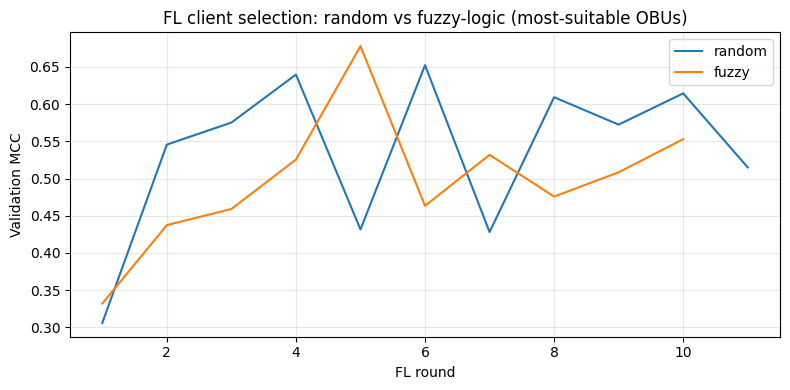


Saved: temporal_fl_participation_compare.csv / .png / temporal_federated_gru_fuzzy.pt


In [18]:
import matplotlib.pyplot as plt

# Fixed config for a FAIR random-vs-fuzzy comparison (small + early-stopped for speed).
# Everything except the participation strategy is held constant.
CMP = dict(fl_rounds=100, client_ratio=0.3, local_epochs=3,
           local_lr=0.001, mu=0.01, dp_sigma=0.1)
print("Comparison config:", CMP)

participation_results, participation_models, participation_conv = {}, {}, {}
for strat in ["random", "fuzzy"]:
    print(f"\n--- participation = {strat} ---")
    vmcc, model, conv = run_fl(participation=strat, verbose=True, **CMP)
    test = gru_eval(model, X_te_s, L_te, y_te)
    participation_results[strat] = dict(val_mcc=vmcc, test_mcc=test["mcc"],
                                        test_acc=test["acc"], test_f1=test["f1"],
                                        rounds_run=len(conv))
    participation_models[strat] = model
    participation_conv[strat]   = conv
    print(f"[{strat}] val MCC={vmcc:.4f}  test MCC={test['mcc']:.4f}  "
          f"F1={test['f1']:.4f}  (rounds={len(conv)})")

cmp_part_df = (pd.DataFrame(participation_results).T
               .reset_index().rename(columns={"index": "participation"}))
cmp_part_df.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_participation_compare.csv"), index=False)
print("\n" + cmp_part_df.to_string(index=False))
gain = participation_results["fuzzy"]["test_mcc"] - participation_results["random"]["test_mcc"]
print(f"\nFuzzy − Random test-MCC gain: {gain:+.4f}")

# Save the fuzzy-selected federated model WITHOUT overwriting temporal_federated_gru.pt
torch.save(participation_models["fuzzy"].state_dict(),
           os.path.join(OUTPUT_DIR, "temporal_federated_gru_fuzzy.pt"))

# Convergence overlay
fig, ax = plt.subplots(figsize=(8, 4))
for strat, conv in participation_conv.items():
    ax.plot(conv["round"], conv["val_mcc"], lw=1.5, label=strat)
ax.set_xlabel("FL round"); ax.set_ylabel("Validation MCC")
ax.set_title("FL client selection: random vs fuzzy-logic (most-suitable OBUs)")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "temporal_fl_participation_compare.png"), dpi=150)
plt.show()
print("\nSaved: temporal_fl_participation_compare.csv / .png / temporal_federated_gru_fuzzy.pt")

## 11. Train Federated GRU with Best Hyperparameters

Train the final federated GRU using the best configuration found in the sensitivity sweep.
Export the model, phi_temp embeddings, and convergence curve.

In [19]:
print("Training federated GRU with best hyperparameters:")
print(f"  fl_rounds={int(best_params['fl_rounds'])} client_ratio={best_params['client_ratio']} "
      f"local_epochs={int(best_params['local_epochs'])} lr={best_params['local_lr']}")
print(f"  mu={best_params['mu']} dp_sigma={best_params['dp_sigma']}")

best_val_mcc, gru_fed, conv_df = run_fl(
    fl_rounds     = int(best_params["fl_rounds"]),
    client_ratio  = best_params["client_ratio"],
    local_epochs  = int(best_params["local_epochs"]),
    local_lr      = best_params["local_lr"],
    mu            = best_params["mu"],
    dp_sigma      = best_params["dp_sigma"],
    verbose       = True
)

res_fed = gru_eval(gru_fed, X_te_s, L_te, y_te)
print(f"\n=== Federated GRU Test === MCC={res_fed['mcc']:.4f}  "
      f"Acc={res_fed['acc']:.4f}  F1={res_fed['f1']:.4f}")

# Export model
torch.save(gru_fed.state_dict(), os.path.join(OUTPUT_DIR, "temporal_federated_gru.pt"))

# Export convergence curve (paper Eq 3.31 — empirical convergence evidence)
conv_df.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_convergence.csv"), index=False)
print("Saved temporal_federated_gru.pt + temporal_fl_convergence.csv")

Training federated GRU with best hyperparameters:
  fl_rounds=250 client_ratio=0.3 local_epochs=3 lr=0.05
  mu=0.01 dp_sigma=0.1


  round 010  val MCC=0.6322  best=0.6768
  early stop round 16

=== Federated GRU Test === MCC=0.6622  Acc=0.9249  F1=0.8281
Saved temporal_federated_gru.pt + temporal_fl_convergence.csv


## 12. Export phi_temp — The Temporal Feature Vector

### What phi_temp is
phi_temp is the 32-dimensional GRU hidden state at the last real beacon in a window.
It is NOT the sigmoid probability output — that is only a training scaffold.
phi_temp feeds into Eq 3.18 (composite detection score) at the vehicle tier.

### What y_hat_i is
y_hat_i = the sigmoid of the GRU's linear head output = per-window Sybil probability.
This is the vehicle-tier detection score before RSU-tier ensemble augmentation.

### How this connects to the ensemble
At the RSU tier, y_hat_i is combined with XGBoost scores:
`y_hat_ens = λ1*y_hat_i + λ2*p_bar_temp + λ3*p_bar_RSSI`   (Eq ensemble_fusion)

In [20]:
def export_phi(model, fname_phi, fname_scores):
    split_arr = np.array(["train"] * len(y_all), dtype=object)
    split_arr[va_idx] = "val"; split_arr[te_idx] = "test"
    phi, prob = extract_phi(model, scale_seq(X_all, L_all, scaler), L_all)
    
    # phi_temp: 32-dim embedding per window
    phi_df = pd.DataFrame({
        "receiver_id":    meta_df["receiver_id"].values,
        "claimed_node_id": meta_df["claimed_node_id"].values,
        "window_start_idx": meta_df["window_start_idx"].values,
        **{f"phi_temp_{i}": phi[:, i] for i in range(phi.shape[1])},
        "y_hat_i":   prob,
        "true_label": meta_df["attack_class"].values,
        "is_sybil":  y_all,
        "split":     split_arr
    })
    phi_df.to_csv(os.path.join(OUTPUT_DIR, fname_phi), index=False)
    
    # Per-vehicle y_hat_i: mean across all windows for this claimed_node_id
    veh_scores = (phi_df.groupby("claimed_node_id")
                  .agg(y_hat_i_mean=("y_hat_i","mean"),
                       y_hat_i_max=("y_hat_i","max"),
                       true_label=("true_label","first"))
                  .reset_index())
    veh_scores.to_csv(os.path.join(OUTPUT_DIR, fname_scores), index=False)
    print(f"Saved {fname_phi} {phi_df.shape}")
    print(f"Saved {fname_scores} {veh_scores.shape}")
    return phi_df, veh_scores

# phi_central_df, veh_central = export_phi(
#     gru_central, "phi_temp_centralized.csv", "y_hat_i_centralized.csv")
phi_fed_df, veh_fed = export_phi(
    gru_fed, "phi_temp_federated.csv", "y_hat_i_federated.csv")
print("\nSample phi_temp (federated):")
print(phi_fed_df.head(3))

Saved phi_temp_federated.csv (11269310, 39)
Saved y_hat_i_federated.csv (467, 4)

Sample phi_temp (federated):
   receiver_id  claimed_node_id  window_start_idx  phi_temp_0  phi_temp_1  \
0           22               53                 0   -0.096504   -0.761497   
1           22               53                 1    0.242599   -0.722938   
2           22               53                 2    0.251708   -0.748611   

   phi_temp_2  phi_temp_3  phi_temp_4  phi_temp_5  phi_temp_6  ...  \
0   -0.196331    0.576531    0.690768   -0.453727    0.628704  ...   
1   -0.210265    0.670844    0.649624   -0.461260    0.710103  ...   
2   -0.202370    0.668395    0.649116   -0.502891    0.695481  ...   

   phi_temp_26  phi_temp_27  phi_temp_28  phi_temp_29  phi_temp_30  \
0     0.936376     0.838327    -0.200635     0.899614    -0.197333   
1     0.825589     0.815009    -0.215890     0.891414     0.019324   
2     0.819580     0.814884    -0.225461     0.888963     0.020255   

   phi_temp_31   y

## 16. Hierarchical FL — Vehicle → RSU → SDN Controller (4-Controller Scenario)

The `seq6_full_s1` scenario runs **4 SDN controllers** over the 64-RSU grid (16 RSUs each), so
the FL aggregation can follow the report's SDVN hierarchy end-to-end each round:

1. **Vehicle / OBU tier** — each selected OBU trains locally (FedProx + DP), exactly as in
   `run_fl` (same `client_update`, same selection strategy).
2. **RSU tier** — each RSU aggregates the updates of the OBUs it serves with a size-weighted
   FedAvg. OBUs map to their **serving RSU geographically** (nearest RSU on the 8×8 grid —
   `OBU_TO_RSU`, Section 10).
3. **SDN-controller tier** — each of the 4 controllers aggregates its RSUs' models with a
   size-weighted FedAvg, using the same RSU→controller index-band assignment as the NS-3
   scenario (RSUs 0–15 → controller 0, 16–31 → 1, 32–47 → 2, 48–63 → 3).
4. **Global** — the 4 controller models are combined by trimmed mean (with only 4 models the
   trim truncates to a plain mean) into the new global model, which is broadcast back down.

It reuses the Section 10 best hyperparameters and compares against the single-hop federated
model (Section 11). New artifacts only — nothing existing is overwritten:
`temporal_federated_gru_hier.pt`, `temporal_fl_hier_convergence.csv` / `.png`.


Training OBUs per SDN controller:
  controller 0:   0 OBUs over  0 RSUs
  controller 1: 139 OBUs over  9 RSUs
  controller 2:  57 OBUs over  8 RSUs
  controller 3:   4 OBUs over  2 RSUs


  round 010  val MCC=0.6469  best=0.6483
  round 020  val MCC=0.8233  best=0.8315
  early stop round 28

=== Hierarchical FL (OBU→RSU→4 controllers) Test === MCC=0.8340  Acc=0.9673  F1=0.9170
vs single-hop federated (Section 11): MCC=0.6622 (delta +0.1718)
vs centralized (Section 9):           MCC=0.9274


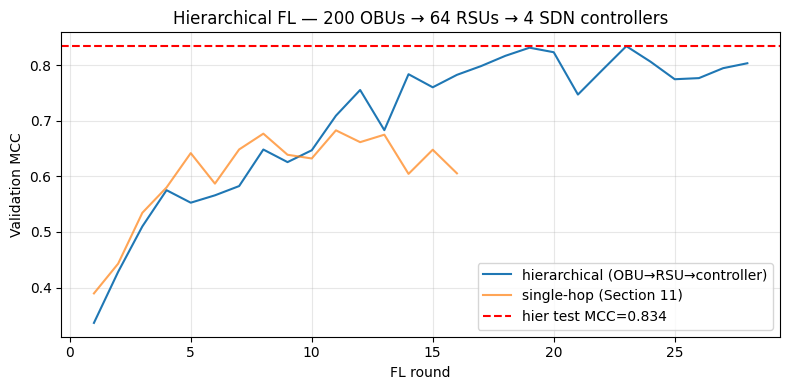

Saved: temporal_federated_gru_hier.pt / temporal_fl_hier_convergence.csv / .png


In [21]:
RUN_CONTROLLER_EXPERIMENT = True   # set False to skip the hierarchical variant

if RUN_CONTROLLER_EXPERIMENT:
    # RSU -> controller: same index-band rule as the NS-3 scenario (16 RSUs each).
    def rsu_to_controller(rsu_id):
        return min(N_CONTROLLERS - 1, int(rsu_id) * N_CONTROLLERS // N_RSUS)

    obu_controller = {rid: rsu_to_controller(OBU_TO_RSU.get(rid, rid % N_RSUS))
                      for rid in client_rids}
    print("Training OBUs per SDN controller:")
    for cc in range(N_CONTROLLERS):
        rids = [r for r, c in obu_controller.items() if c == cc]
        rsus = {OBU_TO_RSU.get(r, r % N_RSUS) for r in rids}
        print(f"  controller {cc}: {len(rids):3d} OBUs over {len(rsus):2d} RSUs")

    def run_fl_hier(fl_rounds, client_ratio, local_epochs, local_lr, mu, dp_sigma,
                    participation="random", verbose=False):
        """Hierarchical FedProx+DP, three aggregation hops per round:
        OBU local update -> serving-RSU weighted FedAvg -> per-controller weighted
        FedAvg -> global trimmed mean over the controller models."""
        torch.manual_seed(RANDOM_SEED)
        gm  = TemporalGRU().to(DEVICE)
        gsd = {k: v.detach().clone() for k, v in gm.state_dict().items()}
        n_select = max(1, int(len(client_rids) * client_ratio))
        best_mcc, best_sd, wait = -1.0, None, 0
        conv = []
        for rnd in range(1, fl_rounds + 1):
            selected = select_clients(client_rids, n_select, strategy=participation,
                                      scores=client_fuzzy_scores)
            # hop 1: local OBU updates, grouped by serving RSU
            by_rsu = {}
            for rid in selected:
                X_c, L_c, y_c = client_map[rid]
                up, sz = client_update(gsd, X_c, L_c, y_c, local_epochs, mu, local_lr, dp_sigma)
                by_rsu.setdefault(OBU_TO_RSU.get(rid, rid % N_RSUS), []).append((up, sz))
            # hop 2: each RSU aggregates its OBUs (size-weighted FedAvg)
            rsu_models, rsu_sizes, rsu_ctrl = [], [], []
            for r, ups in sorted(by_rsu.items()):
                rsu_models.append(weighted_fedavg([u for u, _ in ups], [s for _, s in ups]))
                rsu_sizes.append(sum(s for _, s in ups))
                rsu_ctrl.append(rsu_to_controller(r))
            # hop 3: each SDN controller aggregates its RSUs (size-weighted FedAvg)
            ctrl_models = []
            for cc in sorted(set(rsu_ctrl)):
                idx = [j for j, c in enumerate(rsu_ctrl) if c == cc]
                ctrl_models.append(weighted_fedavg([rsu_models[j] for j in idx],
                                                   [rsu_sizes[j] for j in idx]))
            # top: combine controller models (trimmed mean; k=0 -> plain mean for n=4)
            gsd = trimmed_mean(ctrl_models, FL_TRIM_FRAC)
            gm.load_state_dict(gsd)
            vm = gru_eval(gm, X_va_eval, L_va_eval, y_va_eval)["mcc"]
            conv.append({"round": rnd, "val_mcc": vm, "n_controllers": len(ctrl_models)})
            if vm > best_mcc:
                best_mcc, best_sd, wait = vm, copy.deepcopy(gsd), 0
            else:
                wait += 1
            if verbose and rnd % 10 == 0:
                print(f"  round {rnd:03d}  val MCC={vm:.4f}  best={best_mcc:.4f}")
            if wait >= FL_ES_PATIENCE:
                if verbose:
                    print(f"  early stop round {rnd}")
                break
        if best_sd is not None:
            gm.load_state_dict(best_sd)
        return best_mcc, gm, pd.DataFrame(conv)

    hier_val, gru_hier, hier_conv = run_fl_hier(
        fl_rounds    = int(best_params["fl_rounds"]),
        client_ratio = best_params["client_ratio"],
        local_epochs = int(best_params["local_epochs"]),
        local_lr     = best_params["local_lr"],
        mu           = best_params["mu"],
        dp_sigma     = best_params["dp_sigma"],
        verbose      = True)

    res_hier = gru_eval(gru_hier, X_te_s, L_te, y_te)
    print(f"\n=== Hierarchical FL (OBU→RSU→{N_CONTROLLERS} controllers) Test === "
          f"MCC={res_hier['mcc']:.4f}  Acc={res_hier['acc']:.4f}  F1={res_hier['f1']:.4f}")
    if 'res_fed' in globals():
        print(f"vs single-hop federated (Section 11): MCC={res_fed['mcc']:.4f} "
              f"(delta {res_hier['mcc'] - res_fed['mcc']:+.4f})")
    if 'res_central' in globals():
        print(f"vs centralized (Section 9):           MCC={res_central['mcc']:.4f}")

    torch.save(gru_hier.state_dict(), os.path.join(OUTPUT_DIR, "temporal_federated_gru_hier.pt"))
    hier_conv.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_hier_convergence.csv"), index=False)

    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hier_conv["round"], hier_conv["val_mcc"], lw=1.5,
            label="hierarchical (OBU→RSU→controller)")
    if 'conv_df' in globals():
        ax.plot(conv_df["round"], conv_df["val_mcc"], lw=1.5, alpha=0.7,
                label="single-hop (Section 11)")
    ax.axhline(res_hier["mcc"], color="red", ls="--",
               label=f"hier test MCC={res_hier['mcc']:.3f}")
    ax.set_xlabel("FL round"); ax.set_ylabel("Validation MCC")
    ax.set_title(f"Hierarchical FL — {len(client_rids)} OBUs → {N_RSUS} RSUs → "
                 f"{N_CONTROLLERS} SDN controllers")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "temporal_fl_hier_convergence.png"), dpi=150)
    plt.show()
    print("Saved: temporal_federated_gru_hier.pt / temporal_fl_hier_convergence.csv / .png")
else:
    print("Hierarchical 4-controller experiment skipped (set RUN_CONTROLLER_EXPERIMENT=True).")


## 13. Final Comparison Table

### Expected ordering
Centralized GRU ≥ Federated GRU in performance.
The gap quantifies the cost of:
- **Compactness:** small GRU(32) vs full model
- **Privacy:** DP noise corrupts gradients
- **Distribution:** non-IID OBU data, FedProx regularization

This gap is itself a contribution — it empirically validates the FL framework's privacy-utility tradeoff.

### NS-3 connection
To further validate, re-run NS-3 with different attacker ratios and check that the GRU's
phi_temp embeddings cluster differently for attack vs legitimate identities.
A t-SNE or UMAP plot of phi_temp is a strong visualization for the thesis.

          Model                       Tier  Windows      MCC  Accuracy  F1-macro
Centralized GRU      OBU (neural baseline)  7446694 0.927406  0.985022  0.963266
  Federated GRU OBU (deployed, FedProx+DP)  7446694 0.662189  0.924899  0.828081

Federation cost: MCC gap = 0.2652
Best FL config: rounds=250 mu=0.01 sigma=0.1


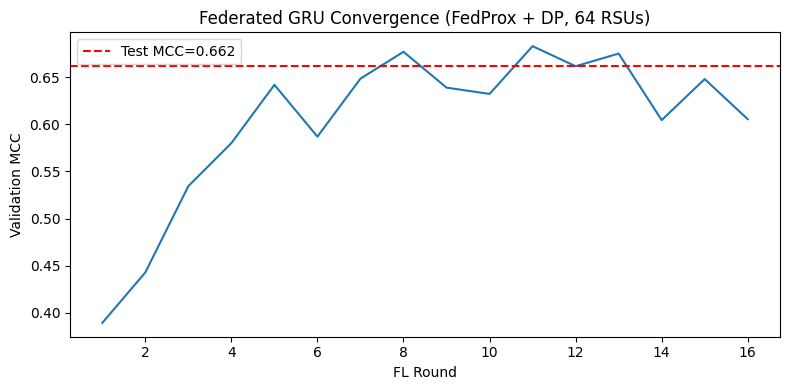


Artifacts saved to: /home/sdvn_defense_sybil/35_sybil_attack_project/ns-allinone-3.35/ns-3.35/sybil-attack/ml/outputs
  temporal_centralized_gru.pt
  temporal_federated_gru.pt
  phi_temp_centralized.csv / phi_temp_federated.csv
  y_hat_i_centralized.csv  / y_hat_i_federated.csv
  temporal_fl_convergence.csv / temporal_fl_sensitivity.csv


,Model,Tier,Windows,MCC,Accuracy,F1-macro
0,Centralized GRU,OBU (neural baseline),7446694,0.927406,0.985022,0.963266
1,Federated GRU,"OBU (deployed, FedProx+DP)",7446694,0.662189,0.924899,0.828081


In [22]:
import matplotlib.pyplot as plt

cmp = pd.DataFrame([
    {"Model": "Centralized GRU", "Tier": "OBU (neural baseline)",
     "Windows": len(X_tr), "MCC": res_central["mcc"],
     "Accuracy": res_central["acc"], "F1-macro": res_central["f1"]},
    {"Model": "Federated GRU",   "Tier": "OBU (deployed, FedProx+DP)",
     "Windows": len(X_tr), "MCC": res_fed["mcc"],
     "Accuracy": res_fed["acc"], "F1-macro": res_fed["f1"]},
])
print("=" * 70)
print(cmp.to_string(index=False))
print("=" * 70)
print(f"\nFederation cost: MCC gap = {res_central['mcc'] - res_fed['mcc']:.4f}")
print(f"Best FL config: rounds={int(best_params['fl_rounds'])} "
      f"mu={best_params['mu']} sigma={best_params['dp_sigma']}")

# Convergence plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(conv_df["round"], conv_df["val_mcc"], lw=1.5)
ax.set_xlabel("FL Round"); ax.set_ylabel("Validation MCC")
ax.set_title(f"Federated GRU Convergence (FedProx + DP, {N_RSUS} RSUs)")
ax.axhline(res_fed["mcc"], color="red", ls="--", label=f"Test MCC={res_fed['mcc']:.3f}")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "temporal_fl_convergence_plot.png"), dpi=150)
plt.show()
print("\nArtifacts saved to:", OUTPUT_DIR)
print("  temporal_centralized_gru.pt")
print("  temporal_federated_gru.pt")
print("  phi_temp_centralized.csv / phi_temp_federated.csv")
print("  y_hat_i_centralized.csv  / y_hat_i_federated.csv")
print("  temporal_fl_convergence.csv / temporal_fl_sensitivity.csv")
cmp

## 14. Second-Stage FL Tuning — Low-DP · Joint Hyperparameters · Smoothed Early-Stop

The Section 10 coordinate sweep varied **one** hyperparameter at a time, so it never tried the
*combination* of each axis's best value, and its DP-noise grid bottomed out at σ=0.05 — still
large for a small GRU. That is why the federated model early-stopped at round 20 with an
oscillating val-MCC curve (0.47 → 0.25) and only reached test MCC ≈ 0.41 vs the centralized 0.875.

This section attacks the three biggest limiters **without touching any earlier cell or overwriting
`temporal_federated_gru.pt`**:

1. **Lower DP noise (A):** σ ∈ {0.001, 0.01} instead of {0.05, 0.1, 0.2}. σ=0.1 added to every
   weight delta each round is the main cause of the oscillation and the ~0.5 val-MCC ceiling.
2. **Joint hyperparameters (B):** a small grid combining the winning coordinate-axis values
   (`client_ratio=0.5`, higher `lr`, `local_epochs=5`) — interactions the coordinate sweep could
   not see.
3. **Smoothed early-stopping (C):** early-stop and best-model selection use a trailing moving
   average of the val MCC, so a single noisy round no longer trips the patience counter.

**How to run:** if your kernel already ran Sections 1–13, everything (`client_map`, `run_fl`,
`res_fed`, `res_central`, `X_te_s`, …) is in memory — just run the three code cells below in order.
From a cold kernel, Run-All from the top first. The stage-2 sweep cell is the slow one
(~8 configs); shrink `STAGE2_GRID` if you want a quick look.

**New outputs (nothing existing is overwritten):**
`temporal_fl_sensitivity_stage2.csv`, `temporal_federated_gru_v2tuned.pt`,
`temporal_fl_convergence_stage2.csv`, `temporal_fl_convergence_stage2.png`.

In [23]:
# ── Smoothed-early-stop FL runner (variant of run_fl; run_fl itself is left untouched) ──
# Identical two-tier FedProx+DP training as run_fl, but early-stop and best-model selection use a
# trailing moving average of the val MCC (length smooth_k) so one noisy round can't end training.
def run_fl_smooth(fl_rounds, client_ratio, local_epochs, local_lr, mu, dp_sigma,
                  participation="random", smooth_k=5, patience=FL_ES_PATIENCE, verbose=False):
    torch.manual_seed(RANDOM_SEED)
    global_model = TemporalGRU().to(DEVICE)
    global_sd = {k: v.detach().clone() for k, v in global_model.state_dict().items()}
    n_select  = max(1, int(len(client_rids) * client_ratio))
    best_smooth, best_sd, wait = -1.0, None, 0
    raw_hist, conv_rows = [], []
    for rnd in range(1, fl_rounds + 1):
        selected = select_clients(client_rids, n_select, strategy=participation,
                                  scores=client_fuzzy_scores)
        uploads, sizes, rsu_ids = [], [], []
        for rid in selected:
            X_c, L_c, y_c = client_map[rid]
            up, sz = client_update(global_sd, X_c, L_c, y_c, local_epochs, mu, local_lr, dp_sigma)
            uploads.append(up); sizes.append(sz)
            rsu_ids.append(OBU_TO_RSU.get(rid, rid % N_RSUS))   # serving RSU (Section 10 map)
        rsu_aggs = []
        for r in sorted(set(rsu_ids)):
            idx = [j for j, rr in enumerate(rsu_ids) if rr == r]
            rsu_aggs.append(weighted_fedavg([uploads[j] for j in idx], [sizes[j] for j in idx]))
        global_sd = trimmed_mean(rsu_aggs, FL_TRIM_FRAC)
        global_model.load_state_dict(global_sd)

        vm = gru_eval(global_model, X_va_eval, L_va_eval, y_va_eval)["mcc"]
        raw_hist.append(vm)
        vm_smooth = float(np.mean(raw_hist[-smooth_k:]))   # trailing moving average
        conv_rows.append({"round": rnd, "val_mcc": vm, "val_mcc_smooth": vm_smooth})

        if vm_smooth > best_smooth:
            best_smooth, best_sd, wait = vm_smooth, copy.deepcopy(global_sd), 0
        else:
            wait += 1
        if verbose and rnd % 10 == 0:
            print(f"  round {rnd:03d}  val MCC={vm:.4f}  smooth={vm_smooth:.4f}  best={best_smooth:.4f}")
        if wait >= patience:
            if verbose:
                print(f"  early stop round {rnd} (smoothed)")
            break
    if best_sd is not None:
        global_model.load_state_dict(best_sd)
    return best_smooth, global_model, pd.DataFrame(conv_rows)

print("run_fl_smooth defined (run_fl untouched).")

run_fl_smooth defined (run_fl untouched).


In [24]:
import time

# "random" currently beats "fuzzy" (Section 10c), so tune at the stronger baseline.
# Flip to "fuzzy" to tune the deployment strategy instead.
STAGE2_PARTICIPATION = "random"

# Joint grid: winning coordinate-axis values x low DP noise.  2 x 2 x 2 = 8 configs.
# local_epochs fixed to 5 (ep=1 was worst in Section 10); fl_rounds capped at 200 (smoothed
# early-stop ends most runs sooner). This is the slow cell — trim the grid for a quick look.
STAGE2_GRID = [
    dict(fl_rounds=200, client_ratio=cr, local_epochs=5, local_lr=lr, mu=0.01, dp_sigma=sg)
    for cr in (0.3, 0.5)
    for lr in (0.01, 0.05)
    for sg in (0.001, 0.01)
]
print(f"Stage-2: {len(STAGE2_GRID)} configs | participation={STAGE2_PARTICIPATION} | smoothed early-stop")

stage2_results = []
for i, c in enumerate(STAGE2_GRID):
    t0 = time.time()
    vmcc, _, _ = run_fl_smooth(participation=STAGE2_PARTICIPATION, smooth_k=5, verbose=False, **c)
    stage2_results.append({**c, "participation": STAGE2_PARTICIPATION, "val_mcc_smooth": vmcc})
    print(f"[{i+1}/{len(STAGE2_GRID)}] ratio={c['client_ratio']} lr={c['local_lr']} "
          f"sigma={c['dp_sigma']} -> val MCC(smooth)={vmcc:.4f}  ({time.time()-t0:.0f}s)")

stage2_df = pd.DataFrame(stage2_results).sort_values("val_mcc_smooth", ascending=False)
stage2_df.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_sensitivity_stage2.csv"), index=False)
best2 = stage2_df.iloc[0].to_dict()
print("\nTop stage-2 configs:")
print(stage2_df.head().to_string(index=False))
print(f"\nBest stage-2: {best2}")

Stage-2: 8 configs | participation=random | smoothed early-stop


[1/8] ratio=0.3 lr=0.01 sigma=0.001 -> val MCC(smooth)=0.7850  (845s)
[2/8] ratio=0.3 lr=0.01 sigma=0.01 -> val MCC(smooth)=0.7939  (1052s)
[3/8] ratio=0.3 lr=0.05 sigma=0.001 -> val MCC(smooth)=0.7742  (780s)
[4/8] ratio=0.3 lr=0.05 sigma=0.01 -> val MCC(smooth)=0.8028  (756s)
[5/8] ratio=0.5 lr=0.01 sigma=0.001 -> val MCC(smooth)=0.7779  (1339s)
[6/8] ratio=0.5 lr=0.01 sigma=0.01 -> val MCC(smooth)=0.7511  (1003s)
[7/8] ratio=0.5 lr=0.05 sigma=0.001 -> val MCC(smooth)=0.7556  (1075s)
[8/8] ratio=0.5 lr=0.05 sigma=0.01 -> val MCC(smooth)=0.7609  (1709s)

Top stage-2 configs:
 fl_rounds  client_ratio  local_epochs  local_lr   mu  dp_sigma participation  val_mcc_smooth
       200           0.3             5      0.05 0.01     0.010        random        0.802785
       200           0.3             5      0.01 0.01     0.010        random        0.793897
       200           0.3             5      0.01 0.01     0.001        random        0.784987
       200           0.5             5   

  round 010  val MCC=0.7075  smooth=0.6583  best=0.6583
  round 020  val MCC=0.7633  smooth=0.7149  best=0.7149
  round 030  val MCC=0.7608  smooth=0.7729  best=0.7739
  round 040  val MCC=0.7872  smooth=0.7701  best=0.7863
  early stop round 41 (smoothed)

=== Tuned Federated GRU Test === MCC=0.8052  Acc=0.9579  F1=0.9008

                Model      MCC      Acc       F1
      Centralized GRU 0.927406 0.985022 0.963266
  Federated GRU (§11) 0.662189 0.924899 0.828081
Federated GRU (tuned) 0.805210 0.957935 0.900815

Tuned - old federated MCC gain: +0.1430
Remaining gap to centralized:  +0.1222


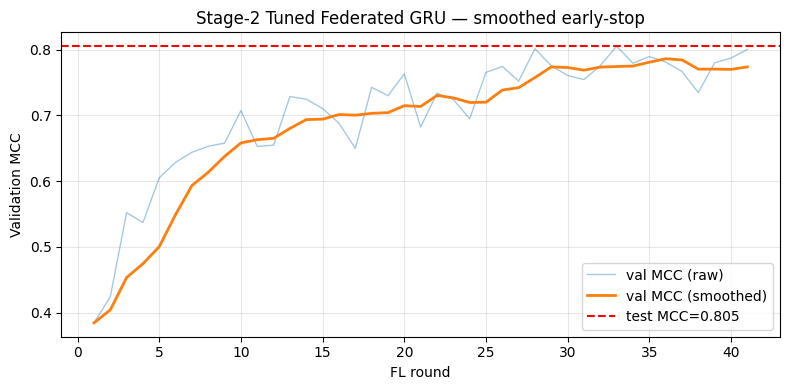


Saved: temporal_federated_gru_v2tuned.pt / temporal_fl_sensitivity_stage2.csv / temporal_fl_convergence_stage2.png


In [25]:
import matplotlib.pyplot as plt

# Retrain the best stage-2 config, evaluate on the FULL test set, compare to the earlier
# federated (res_fed, Section 11) and centralized (res_central, Section 9) models.
best2_val, gru_fed_tuned, conv2_df = run_fl_smooth(
    fl_rounds    = int(best2["fl_rounds"]),
    client_ratio = best2["client_ratio"],
    local_epochs = int(best2["local_epochs"]),
    local_lr     = best2["local_lr"],
    mu           = best2["mu"],
    dp_sigma     = best2["dp_sigma"],
    participation= STAGE2_PARTICIPATION,
    smooth_k     = 5, verbose=True,
)
res_fed_tuned = gru_eval(gru_fed_tuned, X_te_s, L_te, y_te)
print(f"\n=== Tuned Federated GRU Test === MCC={res_fed_tuned['mcc']:.4f}  "
      f"Acc={res_fed_tuned['acc']:.4f}  F1={res_fed_tuned['f1']:.4f}")

# Save WITHOUT overwriting temporal_federated_gru.pt
torch.save(gru_fed_tuned.state_dict(), os.path.join(OUTPUT_DIR, "temporal_federated_gru_v2tuned.pt"))
conv2_df.to_csv(os.path.join(OUTPUT_DIR, "temporal_fl_convergence_stage2.csv"), index=False)

summary = pd.DataFrame([
    {"Model": "Centralized GRU",       "MCC": res_central["mcc"], "Acc": res_central["acc"], "F1": res_central["f1"]},
    {"Model": "Federated GRU (§11)",    "MCC": res_fed["mcc"],     "Acc": res_fed["acc"],     "F1": res_fed["f1"]},
    {"Model": "Federated GRU (tuned)",  "MCC": res_fed_tuned["mcc"],"Acc": res_fed_tuned["acc"],"F1": res_fed_tuned["f1"]},
])
print("\n" + summary.to_string(index=False))
print(f"\nTuned - old federated MCC gain: {res_fed_tuned['mcc'] - res_fed['mcc']:+.4f}")
print(f"Remaining gap to centralized:  {res_central['mcc'] - res_fed_tuned['mcc']:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(conv2_df["round"], conv2_df["val_mcc"], lw=1, alpha=0.4, label="val MCC (raw)")
ax.plot(conv2_df["round"], conv2_df["val_mcc_smooth"], lw=2, label="val MCC (smoothed)")
ax.axhline(res_fed_tuned["mcc"], color="red", ls="--", label=f"test MCC={res_fed_tuned['mcc']:.3f}")
ax.set_xlabel("FL round"); ax.set_ylabel("Validation MCC")
ax.set_title("Stage-2 Tuned Federated GRU — smoothed early-stop")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "temporal_fl_convergence_stage2.png"), dpi=150)
plt.show()
print("\nSaved: temporal_federated_gru_v2tuned.pt / temporal_fl_sensitivity_stage2.csv / "
      "temporal_fl_convergence_stage2.png")